In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [3]:
# Python standard
import os
import sys
import glob

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy import units as u

# PlatoSim functions
import platosim.plot      as pt
import platosim.utilities as ut 
import platosim.starquery as sq
import platosim.smbhb     as bh
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [4]:
# Change path to where you store your downloaded catalogues
path = Path(os.getenv('PLATO_WORKDIR')) / 'plato-go' / 'input'
idir = Path(os.getenv('PLATO_WORKDIR')) / 'runaway_OB_stars'

In [5]:
ds = pd.read_feather(path / 'sources_PlatoCS_LOPS2_v1.ftr')
dn = pd.read_feather(path / 'sources_PlatoCS_LOPN1_v1.ftr')
dt = pd.concat([ds, dn])

In [15]:
# df = pd.read_csv(fdir / 'gosc.aladin', sep='|', skip_blank_lines=True)
df = pd.read_csv(idir / 'CarreteroCastrillo_OBeRunaways_GaiaDR3.csv', sep=' ', 
                 comment='#', names=['GOCS', 'GaiaDR3', 'RA_ICRS', 'DE_ICRS'])
df

ParserError: Error tokenizing data. C error: Expected 4 fields in line 3, saw 14


In [37]:
names = [
    'HD 155913',
    'HD 104565',
    'ALS 18929',
    'ALS 11244',
    'HDE 229232 AB',
    'HD 155775',
    'HD 155775',
    'BD+60134',
    'CPD-342135',
    'HD 12323',
    'AB Cru',
    'HD 192639',
    'HD 94024'
]

In [43]:
# Query sources from Gaia DR3 database
df = pd.DataFrame()
for n in names:
    try:
        dx = sq.simbadQuery(n, radius=15, maglim=21)
        dx['name'] = n
    except:
        print(n)
        pass
    else:
        df = pd.concat([df, dx.iloc[0].to_frame().T])

# Current data frame
cols = list(df)
cols.insert(0, cols.pop(cols.index('name')))
df = df.loc[:, cols]
df = df.drop(columns=['dis'])
df = df.reset_index(drop=True)

# Add galactic coordinates
gal = SkyCoord(df.ra, df.dec, frame='icrs', unit=u.deg).galactic
df['l'] = gal.l.deg
df['b'] = gal.b.deg
df

HDE 229232 AB


,name,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag,l,b
0,HD 155913,5953699131931631232,259.109661,-42.66779,8.176999,0.791308,0.804233,0.026935,-9.735727,4.891813,0.972565,NaN,NaN,7.940016,345.286974,-2.606946
1,HD 104565,6072058878595295488,180.615699,-58.242852,9.074687,0.538304,0.195892,0.013371,-14.087518,5.713472,0.866024,NaN,NaN,8.901955,296.507513,4.016688
2,ALS 18929,4508498643177599744,277.755708,13.503563,11.515334,0.414993,0.648137,0.032237,-6.539137,-2.300991,1.515508,NaN,NaN,11.377976,42.794271,10.571323
3,ALS 11244,2068498409154126720,305.657319,41.674775,10.056318,2.018377,0.570357,0.012355,-6.348474,-3.958111,1.047567,NaN,NaN,9.642939,79.357506,2.613750
4,HD 155775,5973477318881351168,258.843041,-38.212998,6.663964,-0.002746,0.996922,0.035971,3.967761,-6.503806,0.825262,23067.214844,3.5115,6.664957,348.796708,0.145525
5,HD 155775,5973477318881351168,258.843041,-38.212998,6.663964,-0.002746,0.996922,0.035971,3.967761,-6.503806,0.825262,23067.214844,3.5115,6.664957,348.796708,0.145525
6,BD+60134,427457895747434880,14.059227,61.760242,10.397196,0.989754,0.35255,0.01291,-0.082938,-6.442933,0.930346,NaN,NaN,10.117528,123.499675,-1.106215
7,CPD-342135,5546501254035205376,123.397349,-34.478867,9.182691,0.55083,0.293189,0.01311,2.134495,1.811213,0.966596,NaN,NaN,9.006514,252.403420,-0.042984
8,HD 12323,504561286085395712,30.625518,55.623967,8.897508,-0.085841,0.397333,0.032827,-1.349356,-5.690248,0.988553,36393.570312,4.1846,8.928971,132.905290,-5.865652
9,AB Cru,6071508298145817344,184.404574,-58.164561,8.499198,0.246752,0.297372,0.019243,-12.373813,1.235885,0.877485,NaN,NaN,8.414283,298.470563,4.413932


<IPython.core.display.Javascript object>


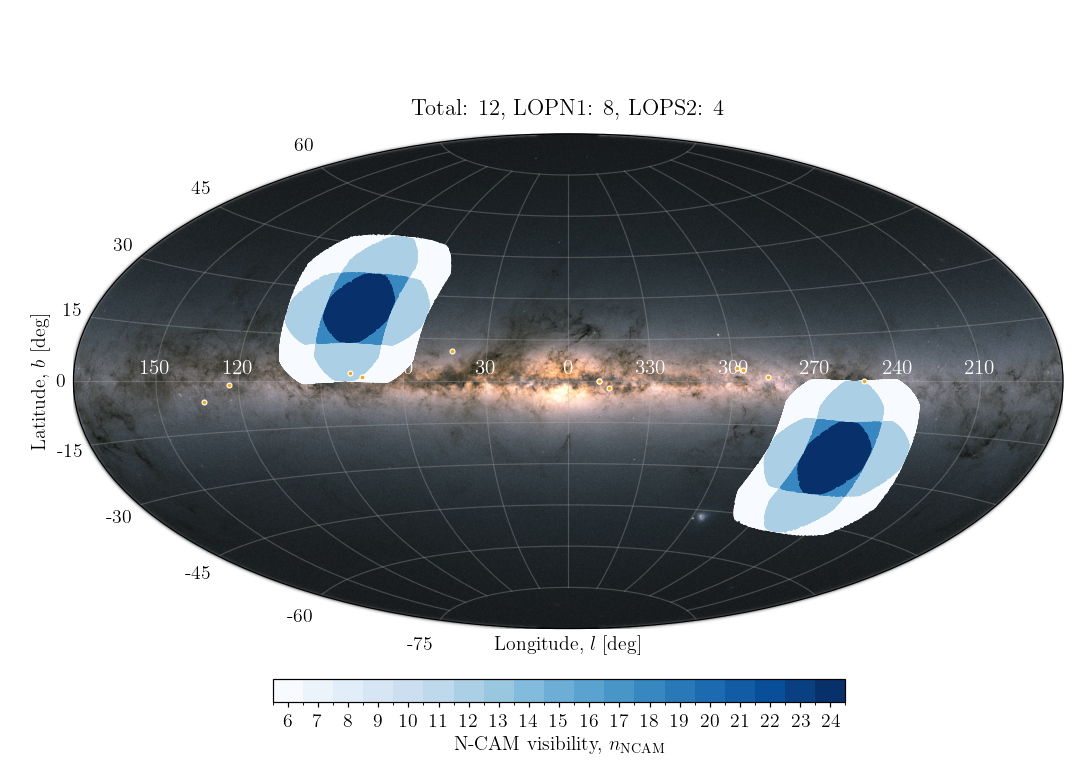

In [44]:
fig, ax = bh.plot_aitoff(dt.iloc[::100], df)
# fig.savefig(fdir / 'aitoff_xray_binary.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


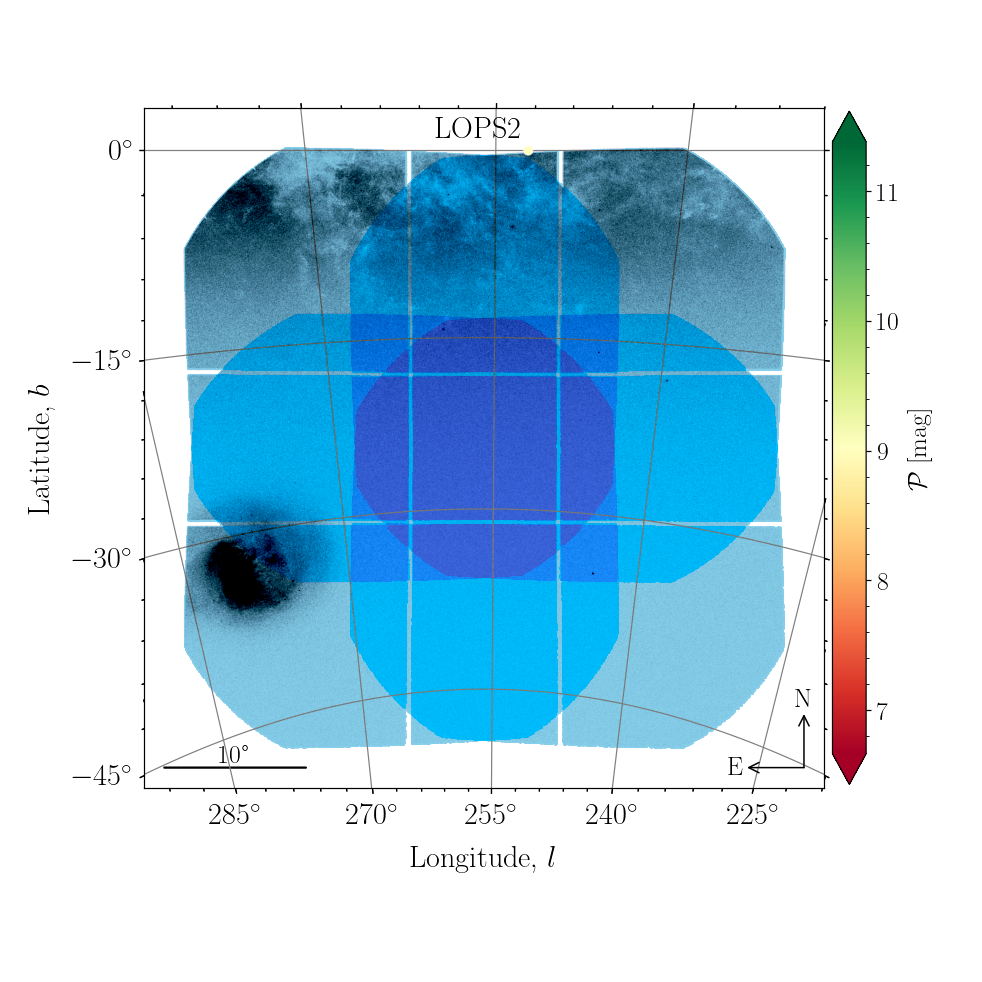

In [46]:
dx = df
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=150, lw=0.4, ec='w',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='RdYlGn', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20);
# fig.savefig(fdir / 'skymap_xray_binary_LOPS2.png', bbox_inches='tight', dpi=200)

In [ ]:
dx = df
fig, ax = pt.plotPlatoFOV('LOPN1', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.2,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPN1', horizontalalignment='center', verticalalignment='center', fontsize=20);
# fig.savefig(fdir / 'skymap_xray_binary_LOPN1.png', bbox_inches='tight', dpi=200)